# Model Training

In [18]:
import os

import tensorflow as tf
import keras
from keras import layers
from keras import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt

from dataclasses import dataclass

keras.__version__

'3.11.3'

## Model Training [20 Points]

All training parameters are defined here. So, this is where you can improve your accuracy and also the architecture.

Here are a few hints on to improve the accuracy:
- Train for a longer duration
- Try with different learning rates
- Try increasing the number of nodes/units in the Dense layers

You need to achieve **at least 85% accuracy** on the **test data** in order to score **10 points**. If you achieve **more than 89% test accuracy**, you end up with a full **20 points**.

In [2]:
is_training = True

In [ ]:
@dataclass
class TrainingConfiguration:
    """
    Describes configuration of the training process
    """

    # batch_size: int = 32
    # epochs_count: int = 2
    # learning_rate: float = 0.1

    # update changed parameters in the below coding block.
    batch_size: int = 50
    epochs_count: int = 25
    learning_rate: float = 0.00000005

    ###
    ### YOUR CODE HERE
    ###

### 1.1 Model Definition

You need to define your model here. Recall that each image in the dataset has a size of `28 x 28`, so your `input_shape` should have a size of: `(28,28)`. Also, don’t forget, you need to implement a very simple MLP here, with only a few `Dense` layers. Have a look at this block diagram representing a simple MLP. 

<img src = "https://learnopencv.com/wp-content/uploads/2022/02/c4_02_mlps_fashion_mnist.png" width=950 align='center'><br/>

The time required to train your model on the course site should be roughly **2-3 minutes**.


**Note: Remember to use a `softmax` activation for the output layer.**

/Users/tapasyagutta/workspace/deep-learning/.tkVenv/lib/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
(60000, 784)
(10000, 784)
4


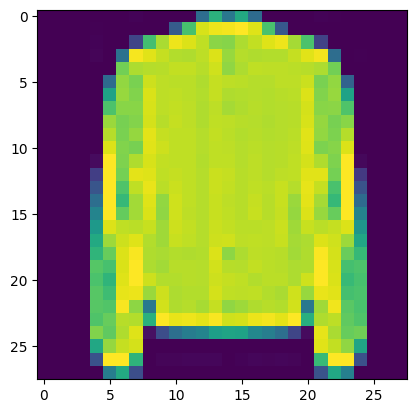

In [4]:
%run -i data.ipynb

In [93]:
def get_model():
    """
    You need to define your MLP model here.
    """

    model = Sequential()
    model.add(keras.Input(shape=(784,)))
    model.add(Dense(660, activation="relu", use_bias=True))
    model.add(Dense(545, activation="relu", use_bias=True))
    model.add(Dense(489, activation="relu", use_bias=True))
    model.add(Dense(320, activation="relu", use_bias=True))
    model.add(Dense(125, activation="relu", use_bias=True))
    model.add(Dense(10, activation="softmax"))

    ###
    ### YOUR CODE HERE
    ###

    return model

### 1.2 Display the model

In [94]:
tf.random.set_seed(42)

model_fmnist = get_model()

print(model_fmnist.summary())

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 660)            │       518,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 545)            │       360,245 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 489)            │       266,994 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 320)            │       156,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 125)            │        40,125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │         1,260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,343,524 (5.13 MB)

 Trainable params: 1,343,524 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

None


### 1.3 Create directory to save final model

In [19]:
if not os.path.exists("models"):
    os.makedirs("models")

### 1.4 Main

Let’s use the configuration parameters defined above and start training.

In [95]:
def compile_and_train_model(train_set, test_set, model, training_configuration):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=training_configuration.learning_rate
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"],
    )

    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        "./models/fashion_mnist_final_50_25_00000155.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
    )

    history = model.fit(
        train_set[0],
        train_set[1],
        batch_size=training_configuration.batch_size,
        epochs=training_configuration.epochs_count,
        validation_data=test_set,
        callbacks=[
            checkpoint_callback,
        ],
    )

    return model, history

In [ ]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


In [ ]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


### 1.5 Start training

In [96]:
training_configuration = TrainingConfiguration()

train_set = (X_train, y_train)
test_set = (X_test, y_test)

if is_training:
    model_final, training_results = compile_and_train_model(
        train_set, test_set, model_fmnist, training_configuration
    )

Epoch 1/25
1198/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3046 - loss: 2.1649

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4660 - loss: 1.9778 - val_accuracy: 0.6427 - val_loss: 1.5435
Epoch 2/25
1198/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6850 - loss: 1.3336

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6978 - loss: 1.1747 - val_accuracy: 0.7139 - val_loss: 0.9417
Epoch 3/25
1195/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7345 - loss: 0.8716

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7459 - loss: 0.8250 - val_accuracy: 0.7549 - val_loss: 0.7617
Epoch 4/25
1196/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7727 - loss: 0.7224

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.7775 - loss: 0.7012 - val_accuracy: 0.7773 - val_loss: 0.6798
Epoch 5/25
1197/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7919 - loss: 0.6488

...

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8561 - loss: 0.4172 - val_accuracy: 0.8431 - val_loss: 0.4474
Epoch 22/25
1195/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8565 - loss: 0.4158

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8576 - loss: 0.4128 - val_accuracy: 0.8437 - val_loss: 0.4438
Epoch 23/25
1195/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8577 - loss: 0.4117

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8586 - loss: 0.4088 - val_accuracy: 0.8444 - val_loss: 0.4403
Epoch 24/25
1199/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8591 - loss: 0.4078

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8600 - loss: 0.4050 - val_accuracy: 0.8458 - val_loss: 0.4370
Epoch 25/25
1196/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8603 - loss: 0.4041

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8610 - loss: 0.4013 - val_accuracy: 0.8468 - val_loss: 0.4340


### 1.7 Plot Loss

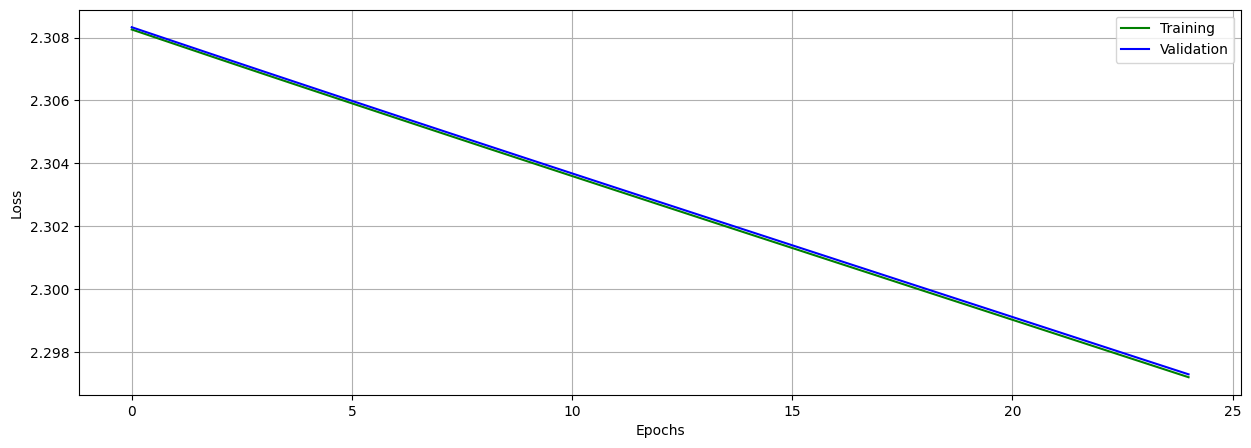

In [90]:
plt.figure(figsize=[15, 5])
plt.plot(training_results.history["loss"], "g")
plt.plot(training_results.history["val_loss"], "b")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend(["Training", "Validation"], loc="upper right")
plt.grid(True)

### 1.7 Plot Accuracy

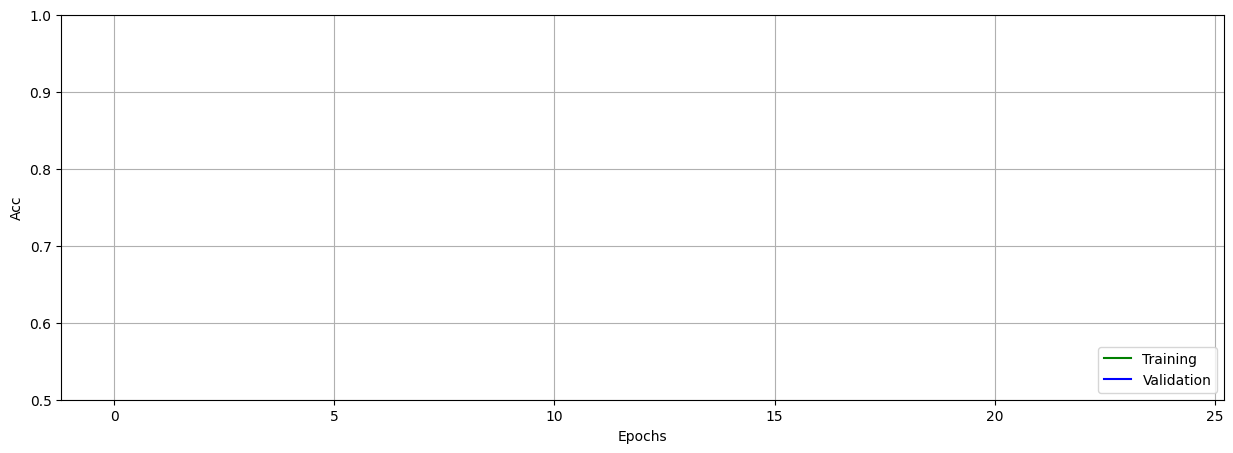

In [91]:
plt.figure(figsize=[15, 5])
plt.plot(training_results.history["accuracy"], "g")
plt.plot(training_results.history["val_accuracy"], "b")

plt.ylim([0.5, 1])

plt.xlabel("Epochs")
plt.ylabel("Acc")

plt.legend(["Training", "Validation"], loc="lower right")
plt.grid(True)